<a href="https://colab.research.google.com/github/disha25taneja-web/telco-customer-churn-analysis/blob/main/telco_customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
cus

In [ ]:
print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)
print("\nDuplicate customer IDs:", df["customerID"].duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())
print("\nContract types:")
print(df["Contract"].value_counts())
print("\nInternet service types:")
print(df["InternetService"].value_counts())
print("\nPayment methods:")
print(df["PaymentMethod"].value_counts())

Dataset shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Duplicate customer IDs: 0

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Contract types:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Internet service types:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Payment methods:
PaymentMethod
Electr

In [ ]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("Values that cannot be converted to numbers:")
print(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "TotalCharges"]])

Values that cannot be converted to numbers:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

Missing TotalCharges: 11


In [ ]:
df.loc[
    (df["tenure"] == 0) & (df["TotalCharges"].isna()),
    "TotalCharges"
] = 0
print("Missing TotalCharges after cleaning:", df["TotalCharges"].isna().sum())

Missing TotalCharges after cleaning: 0


In [ ]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
print("Dataset shape:", df.shape)
print("\nTotal missing values:", df.isnull().sum().sum())
print("\nDuplicate customer IDs:", df["customerID"].duplicated().sum())

Dataset shape: (7043, 21)

Total missing values: 0

Duplicate customer IDs: 0


In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
df.to_csv("/content/telco_customer_churn_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
!pip install duckdb duckdb-engine jupysql --quiet
%load_ext sql
%config SqlMagic.autopandas = True
%sql duckdb:///:memory:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.7/567.7 kB 25.7 MB/s eta 0:00:00


Connecting to 'duckdb:///:memory:'

In [ ]:
%%sql
CREATE TABLE customers (
    customerID VARCHAR(20),
    gender VARCHAR(20),
    SeniorCitizen INTEGER,
    Partner VARCHAR(10),
    Dependents VARCHAR(10),
    tenure INTEGER,
    PhoneService VARCHAR(10),
    MultipleLines VARCHAR(30),
    InternetService VARCHAR(30),
    OnlineSecurity VARCHAR(30),
    OnlineBackup VARCHAR(30),
    DeviceProtection VARCHAR(30),
    TechSupport VARCHAR(30),
    StreamingTV VARCHAR(30),
    StreamingMovies VARCHAR(30),
    Contract VARCHAR(30),
    PaperlessBilling VARCHAR(10),
    PaymentMethod VARCHAR(50),
    MonthlyCharges NUMERIC(10,2),
    TotalCharges NUMERIC(10,2),
    Churn VARCHAR(10)
);

Running query in 'duckdb:///:memory:'

,Success


In [ ]:
%%sql
SELECT * FROM customers;

Running query in 'duckdb:///:memory:'

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
%%sql
COPY  customers (customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, Multiplelines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, churn)
FROM '/telco_customer_churn_cleaned.csv'
DELIMITER ','
CSV HEADER;

Running query in 'duckdb:///:memory:'

,Success


In [ ]:
import os
print(os.path.exists('/content/telco_customer_churn_cleaned.csv'))

True


In [ ]:
%%sql
SELECT * FROM customers LIMIT 5;

Running query in 'duckdb:///:memory:'

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
%%sql
SELECT COUNT(*) AS total_customers FROM customers;

Running query in 'duckdb:///:memory:'

,total_customers
0,7043


In [ ]:
%%sql
SELECT "Churn", COUNT(*) AS customers,
    ROUND(COUNT() * 100.0 / (SELECT COUNT() FROM customers), 2) AS churn_percentage
FROM customers
GROUP BY "Churn"
ORDER BY "Churn";

Running query in 'duckdb:///:memory:'

,Churn,customers,churn_percentage
0,No,5174,73.46
1,Yes,1869,26.54


In [ ]:
%%sql
SELECT "Contract", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Contract"
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655.0,42.71
1,One year,1473,166.0,11.27
2,Two year,1695,48.0,2.83


In [ ]:
%%sql
SELECT "InternetService", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "InternetService"
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,InternetService,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297.0,41.89
1,DSL,2421,459.0,18.96
2,No,1526,113.0,7.40


In [ ]:
%%sql
SELECT "PaymentMethod", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "PaymentMethod"
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071.0,45.29
1,Mailed check,1612,308.0,19.11
2,Bank transfer (automatic),1544,258.0,16.71
3,Credit card (automatic),1522,232.0,15.24


In [ ]:
%%sql
SELECT
    CASE
        WHEN "tenure" <= 12 THEN '0-12 months'
        WHEN "tenure" <= 24 THEN '13-24 months'
        WHEN "tenure" <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,tenure_group,total_customers,churned_customers,churn_rate
0,0-12 months,2186,1037.0,47.44
1,13-24 months,1024,294.0,28.71
2,25-48 months,1594,325.0,20.39
3,49+ months,2239,213.0,9.51


In [ ]:
%%sql
SELECT
    CASE
        WHEN "MonthlyCharges" < 40 THEN 'Below $40'
        WHEN "MonthlyCharges" < 70 THEN '$40-$69'
        WHEN "MonthlyCharges" < 100 THEN '$70-$99'
        ELSE '$100+'
    END AS charge_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY charge_group
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,charge_group,total_customers,churned_customers,churn_rate
0,$70-$99,2683,1017.0,37.91
1,$100+,908,257.0,28.30
2,$40-$69,1615,382.0,23.65
3,Below $40,1837,213.0,11.59


In [ ]:
%%sql
SELECT "SeniorCitizen",COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "SeniorCitizen"
ORDER BY churn_rate DESC;


Running query in 'duckdb:///:memory:'

,SeniorCitizen,total_customers,churned_customers,churn_rate
0,1,1142,476.0,41.68
1,0,5901,1393.0,23.61


In [ ]:
%%sql
SELECT "Partner",COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Partner"
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Partner,total_customers,churned_customers,churn_rate
0,No,3641,1200.0,32.96
1,Yes,3402,669.0,19.66


In [ ]:
%%sql
SELECT"Dependents",COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Dependents"
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Dependents,total_customers,churned_customers,churn_rate
0,No,4933,1543.0,31.28
1,Yes,2110,326.0,15.45


In [ ]:
%%sql
SELECT "Contract", "PaymentMethod", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Contract", "PaymentMethod"
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Contract,PaymentMethod,total_customers,churned_customers,churn_rate
0,Month-to-month,Electronic check,1850,994.0,53.73
1,Month-to-month,Bank transfer (automatic),589,201.0,34.13
2,Month-to-month,Credit card (automatic),543,178.0,32.78
3,Month-to-month,Mailed check,893,282.0,31.58
4,One year,Electronic check,347,64.0,18.44
5,One year,Credit card (automatic),398,41.0,10.30
6,One year,Bank transfer (automatic),391,38.0,9.72
7,Two year,Electronic check,168,13.0,7.74
8,One year,Mailed check,337,23.0,6.82
9,Two year,Bank transfer (automatic),564,19.0,3.37


In [ ]:
%%sql
SELECT "Contract",
    CASE
        WHEN "tenure" <= 12 THEN '0-12 months'
        WHEN "tenure" <= 24 THEN '13-24 months'
        WHEN "tenure" <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    "PaymentMethod",
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Contract",tenure_group,"PaymentMethod"
HAVING COUNT(*) >= 30
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Contract,tenure_group,PaymentMethod,total_customers,churned_customers,churn_rate
0,Month-to-month,0-12 months,Electronic check,954,602.0,63.10
1,Month-to-month,13-24 months,Electronic check,355,182.0,51.27
2,Month-to-month,0-12 months,Bank transfer (automatic),208,101.0,48.56
3,Month-to-month,0-12 months,Credit card (automatic),191,79.0,41.36
4,Month-to-month,25-48 months,Electronic check,376,154.0,40.96
5,Month-to-month,0-12 months,Mailed check,641,242.0,37.75
6,Month-to-month,49+ months,Electronic check,165,56.0,33.94
7,Month-to-month,13-24 months,Credit card (automatic),121,38.0,31.40
8,Month-to-month,25-48 months,Bank transfer (automatic),172,52.0,30.23
9,Month-to-month,25-48 months,Credit card (automatic),159,44.0,27.67


In [ ]:
%%sql
SELECT "OnlineSecurity", "TechSupport", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "OnlineSecurity", "TechSupport"
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,OnlineSecurity,TechSupport,total_customers,churned_customers,churn_rate
0,No,No,2553,1250.0,48.96
1,No,Yes,945,211.0,22.33
2,Yes,No,920,196.0,21.30
3,Yes,Yes,1099,99.0,9.01
4,No internet service,No internet service,1526,113.0,7.40


In [ ]:
%%sql
SELECT "PhoneService", "MultipleLines", COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "PhoneService", "MultipleLines"
HAVING COUNT(*) >= 50
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,PhoneService,MultipleLines,total_customers,churned_customers,churn_rate
0,Yes,Yes,2971,850.0,28.61
1,Yes,No,3390,849.0,25.04
2,No,No phone service,682,170.0,24.93


In [ ]:
%%sql
SELECT "Contract", "PaymentMethod",
    CASE
        WHEN "tenure" <= 12 THEN '0-12 months'
        WHEN "tenure" <= 24 THEN '13-24 months'
        WHEN "tenure" <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_group,
    CASE
        WHEN "MonthlyCharges" < 70 THEN 'Below $70'
        ELSE '$70+'
    END AS charge_group,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(SUM(CASE WHEN "Churn" = 'Yes' THEN 1 ELSE 0 END) * 100.0/ COUNT(*),2) AS churn_rate
FROM customers
GROUP BY "Contract", "PaymentMethod", tenure_group,charge_group
HAVING COUNT(*) >= 30
ORDER BY churn_rate DESC;

Running query in 'duckdb:///:memory:'

,Contract,PaymentMethod,tenure_group,charge_group,total_customers,churned_customers,churn_rate
0,Month-to-month,Bank transfer (automatic),0-12 months,$70+,82,65.0,79.27
1,Month-to-month,Electronic check,0-12 months,$70+,588,413.0,70.24
2,Month-to-month,Credit card (automatic),0-12 months,$70+,75,47.0,62.67
3,Month-to-month,Mailed check,0-12 months,$70+,115,70.0,60.87
4,Month-to-month,Electronic check,13-24 months,$70+,256,148.0,57.81
5,Month-to-month,Electronic check,0-12 months,Below $70,366,189.0,51.64
6,Month-to-month,Electronic check,25-48 months,$70+,292,140.0,47.95
7,Month-to-month,Credit card (automatic),13-24 months,$70+,64,28.0,43.75
8,Month-to-month,Bank transfer (automatic),25-48 months,$70+,110,41.0,37.27
9,Month-to-month,Electronic check,49+ months,$70+,138,50.0,36.23


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:
cus

Customer Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


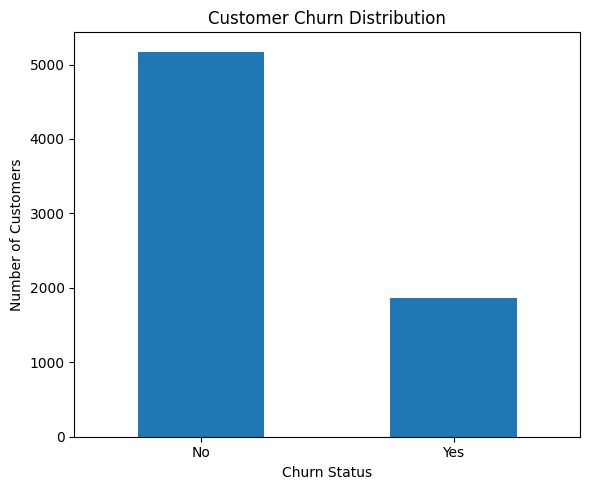

In [ ]:
import matplotlib.pyplot as plt
churn_counts = df["Churn"].value_counts()
print("Customer Churn Distribution:")
print(churn_counts)
print("\nChurn Percentage:")
print((churn_counts / len(df) * 100).round(2))
plt.figure(figsize=(6, 5))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Monthly Charges by Churn Status:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


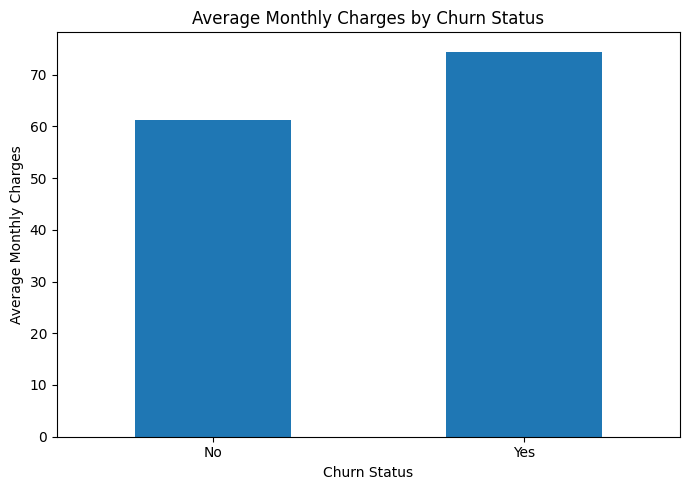

In [ ]:
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean().round(2)
print("Average Monthly Charges by Churn Status:")
print(avg_charges)
plt.figure(figsize=(7, 5))
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Tenure by Churn Status:
Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


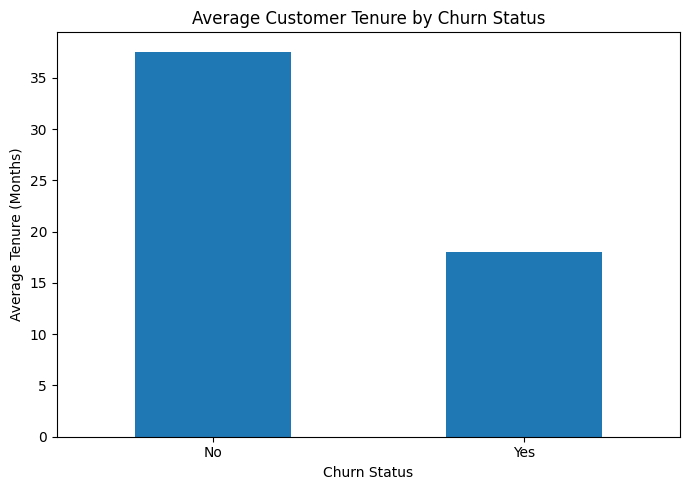

In [ ]:
avg_tenure = df.groupby("Churn")["tenure"].mean().round(2)
print("Average Tenure by Churn Status:")
print(avg_tenure)
plt.figure(figsize=(7, 5))
df.groupby("Churn")["tenure"].mean().plot(kind="bar")
plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Churn Percentage by Contract Type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


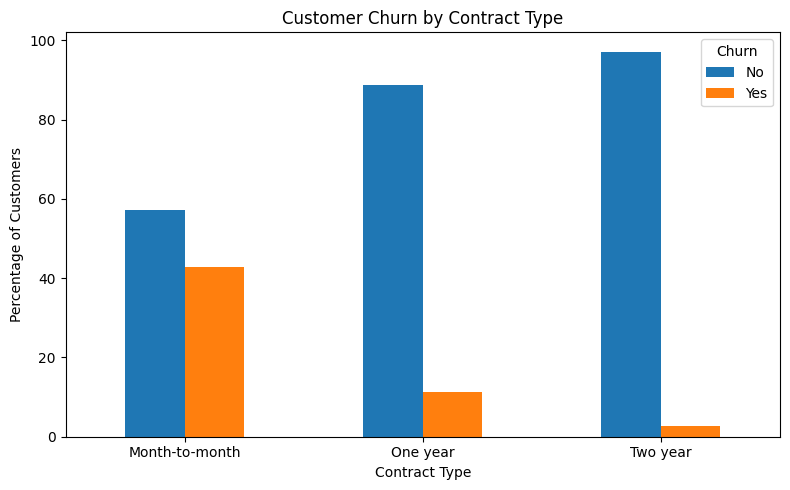

In [ ]:
contract_churn = pd.crosstab(df["Contract"],df["Churn"],normalize="index") * 100
contract_churn = contract_churn.round(2)
print("Churn Percentage by Contract Type:")
print(contract_churn)
contract_churn.plot(
    kind="bar",figsize=(8, 5))
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

Churn Percentage by Payment Method:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


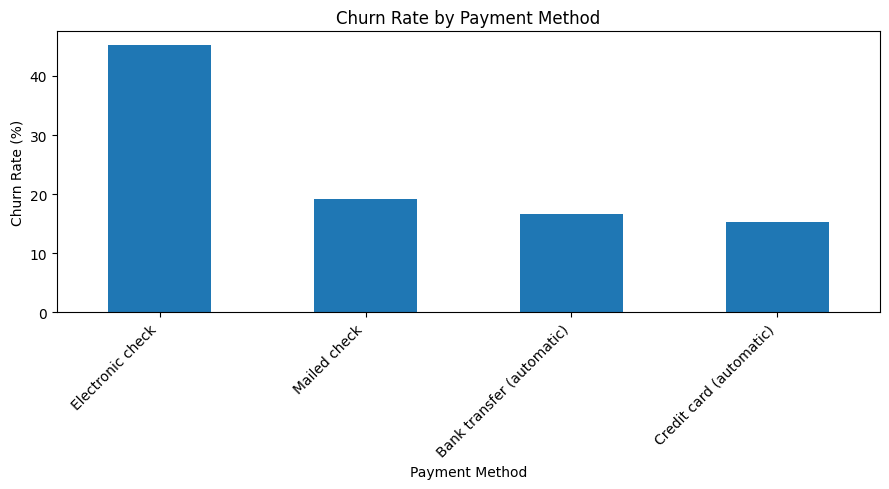

In [ ]:
payment_churn = pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index") * 100
payment_churn = payment_churn.round(2)
print("Churn Percentage by Payment Method:")
print(payment_churn)
payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Churn Percentage by Internet Service:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


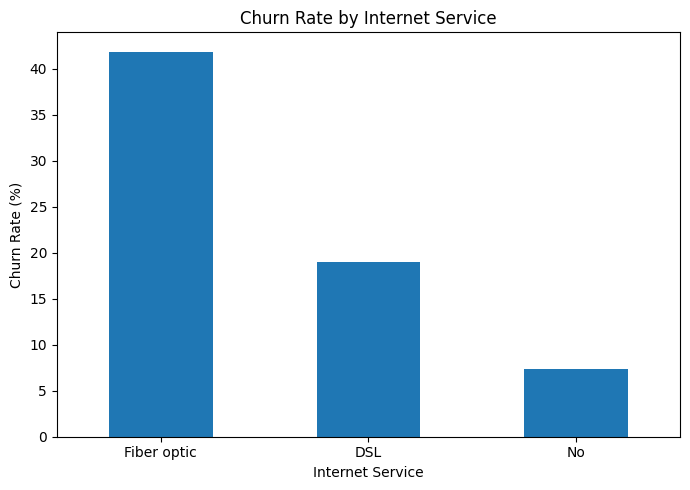

In [ ]:
internet_churn = pd.crosstab(df["InternetService"],df["Churn"],normalize="index") * 100
internet_churn = internet_churn.round(2)
print("Churn Percentage by Internet Service:")
print(internet_churn)
internet_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Churn Percentage by Online Security and Tech Support:
Churn                                       No    Yes
OnlineSecurity      TechSupport                      
No                  No                   51.04  48.96
                    Yes                  77.67  22.33
No internet service No internet service  92.60   7.40
Yes                 No                   78.70  21.30
                    Yes                  90.99   9.01


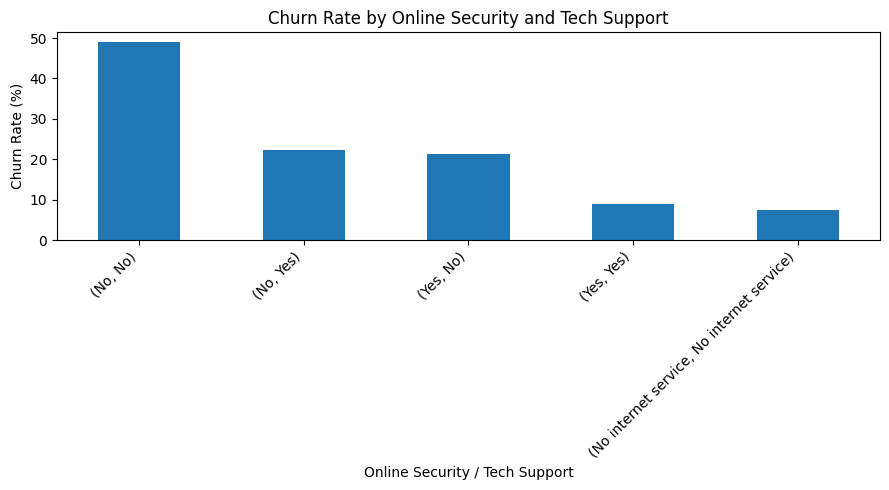

In [ ]:
support_churn = pd.crosstab([df["OnlineSecurity"], df["TechSupport"]],df["Churn"],normalize="index") * 100
support_churn = support_churn.round(2)
print("Churn Percentage by Online Security and Tech Support:")
print(support_churn)
support_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Churn Rate by Online Security and Tech Support")
plt.xlabel("Online Security / Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Churn Percentage by Paperless Billing:
Churn                No    Yes
PaperlessBilling              
No                83.67  16.33
Yes               66.43  33.57


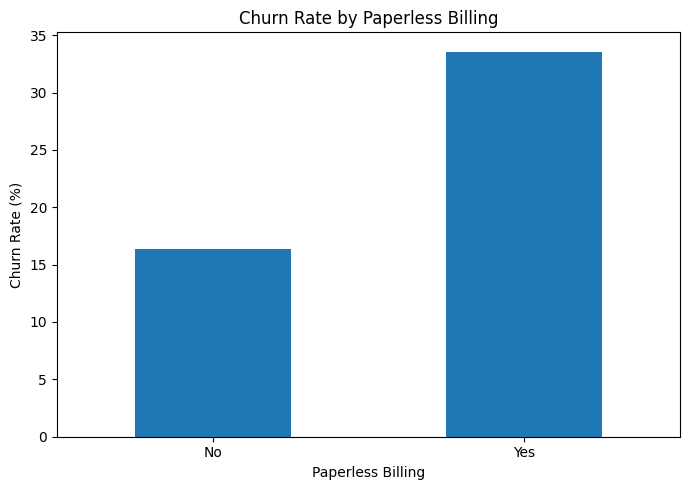

In [ ]:
billing_churn = pd.crosstab(df["PaperlessBilling"],df["Churn"],normalize="index") * 100
billing_churn = billing_churn.round(2)
print("Churn Percentage by Paperless Billing:")
print(billing_churn)
billing_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#using machine learning
ml_df = df.copy()
print("ML Dataset Shape:", ml_df.shape)
print("\nTarget Variable:")
print(ml_df["Churn"].value_counts())

ML Dataset Shape: (7043, 21)

Target Variable:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
ml_df["Churn"] = ml_df["Churn"].map({"No": 0, "Yes": 1})
print("Target variable after encoding:")
print(ml_df["Churn"].value_counts())
print("\nTarget data type:")
print(ml_df["Churn"].dtype)

Target variable after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target data type:
int64


In [ ]:
X = ml_df.drop(columns=["Churn", "customerID"])
y = ml_df["Churn"]
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features (X) shape: (7043, 19)
Target (y) shape: (7043,)

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (5634, 19)
Testing set: (1409, 19)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ])
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])
print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [ ]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
y_pred = logistic_model.predict(X_test)
print("Predictions generated successfully.")
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [ ]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8070
Precision: 0.6604
Recall   : 0.5615
F1 Score : 0.6069
ROC-AUC  : 0.8422

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[927 108]
 [164 210]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))])
print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [ ]:
random_forest_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)
print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Performance
-------------------------
Accuracy : 0.7899
Precision: 0.6327
Recall   : 0.4973
F1 Score : 0.5569
ROC-AUC  : 0.8255

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[927 108]
 [188 186]]


In [ ]:
#using logistic regression function as it is best
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coef_df = coef_df.sort_values("Coefficient", ascending=False)
print("Top 10 features associated with higher churn:")
print(coef_df.head(10))
print("\nTop 10 features associated with lower churn:")
print(coef_df.tail(10))

Top 10 features associated with higher churn:
                                Feature  Coefficient
10     cat__InternetService_Fiber optic     1.182298
3                     num__TotalCharges     0.523110
28  cat__PaymentMethod_Electronic check     0.383863
21                 cat__StreamingTV_Yes     0.377500
23             cat__StreamingMovies_Yes     0.376065
26            cat__PaperlessBilling_Yes     0.371284
9                cat__MultipleLines_Yes     0.362275
29      cat__PaymentMethod_Mailed check     0.075442
0                    num__SeniorCitizen     0.054651
17            cat__DeviceProtection_Yes     0.035237

Top 10 features associated with lower churn:
                                    Feature  Coefficient
12  cat__OnlineSecurity_No internet service    -0.173381
6                       cat__Dependents_Yes    -0.224945
8       cat__MultipleLines_No phone service    -0.256658
19                     cat__TechSupport_Yes    -0.297591
13                  cat__OnlineSecurity_

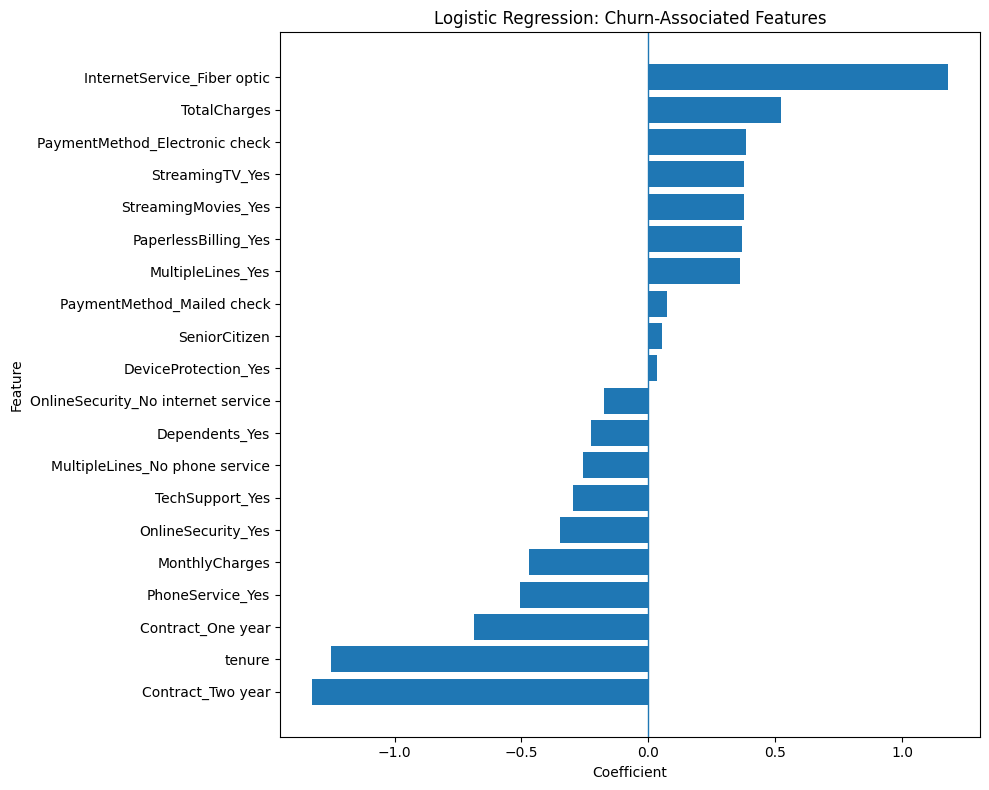

In [ ]:
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
coef_plot_df = pd.concat([top_positive, top_negative])
coef_plot_df["Feature"] = (
    coef_plot_df["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)
coef_plot_df = coef_plot_df.sort_values("Coefficient")
plt.figure(figsize=(10, 8))
plt.barh(
    coef_plot_df["Feature"],
    coef_plot_df["Coefficient"]
)
plt.axvline(0, linewidth=1)
plt.title("Logistic Regression: Churn-Associated Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

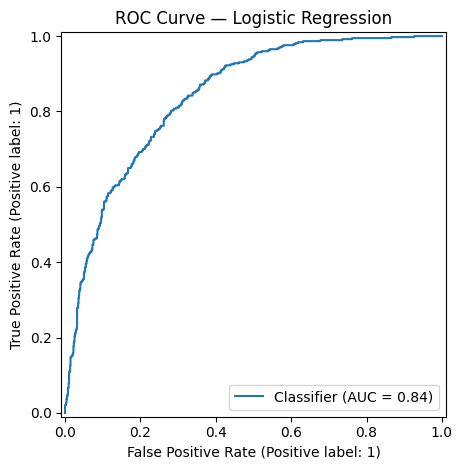

In [ ]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.title("ROC Curve — Logistic Regression")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

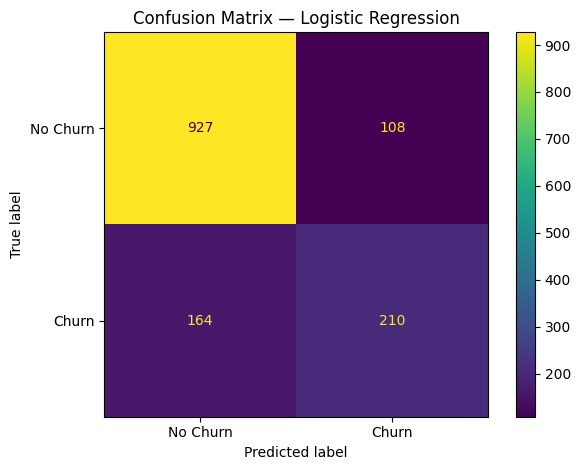

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()